In [ ]:
# import Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import needed packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

## Import Data for Glioma Grading

In [ ]:
# import data
initialdata = pd.read_csv('/content/drive/MyDrive/MSBD 566 Predictive Modeling /Mid-Term Project/glioma+grading+clinical+and+mutation+features+dataset/TCGA_InfoWithGrade.csv')
initialdata.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Check for missing values and dataset shape

In [ ]:
initialdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Grade             839 non-null    int64  
 1   Gender            839 non-null    int64  
 2   Age_at_diagnosis  839 non-null    float64
 3   Race              839 non-null    int64  
 4   IDH1              839 non-null    int64  
 5   TP53              839 non-null    int64  
 6   ATRX              839 non-null    int64  
 7   PTEN              839 non-null    int64  
 8   EGFR              839 non-null    int64  
 9   CIC               839 non-null    int64  
 10  MUC16             839 non-null    int64  
 11  PIK3CA            839 non-null    int64  
 12  NF1               839 non-null    int64  
 13  PIK3R1            839 non-null    int64  
 14  FUBP1             839 non-null    int64  
 15  RB1               839 non-null    int64  
 16  NOTCH1            839 non-null    int64  
 1

## Check the Distribution of the Demographic Variables

,Age_at_diagnosis
count,839.000000
mean,50.935411
std,15.702339
min,14.420000
25%,38.055000
50%,51.550000
75%,62.800000
max,89.290000


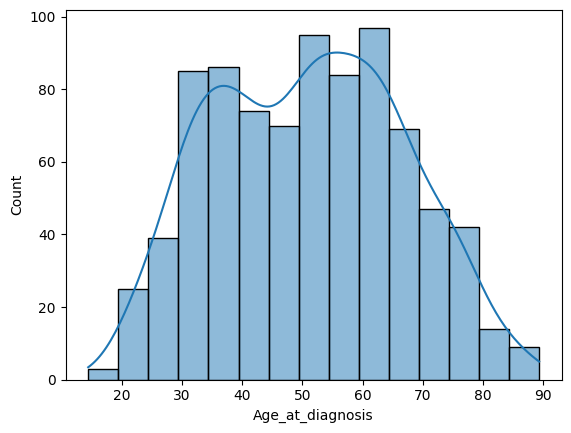

In [ ]:
display(initialdata['Age_at_diagnosis'].describe())

# distribution graph of age
sns.histplot(initialdata['Age_at_diagnosis'], kde = True)
plt.show()

,count
Grade,
0,487
1,352


,count
Grade,
0,58.045292
1,41.954708


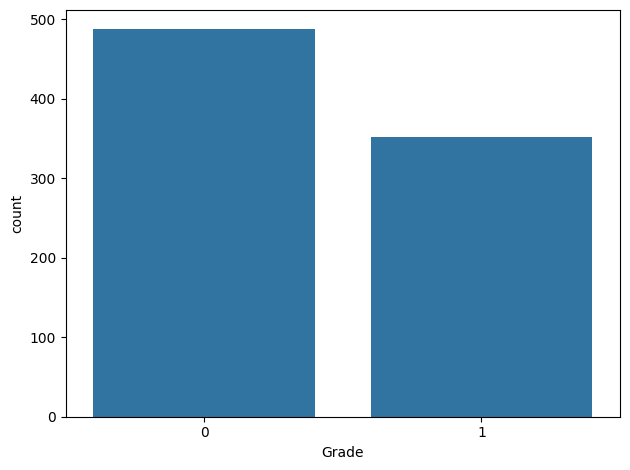

In [ ]:
grade_data = initialdata['Grade'].value_counts()
display(grade_data)
display(grade_data * 100 / len(initialdata))

sns.countplot(data = initialdata, x = 'Grade')
plt.tight_layout()
plt.show()

Gender
0    488
1    351
Name: count, dtype: int64


,count
Gender,
0,58.164482
1,41.835518


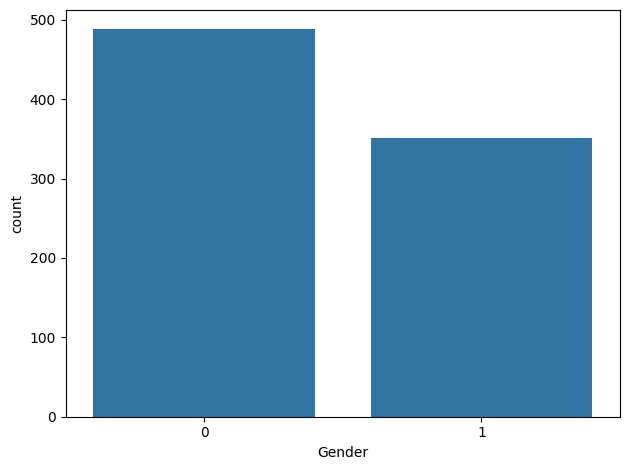

In [ ]:
gender_data = initialdata['Gender'].value_counts()
print(gender_data)

display(gender_data * 100 / len(initialdata))

sns.countplot(data = initialdata, x = 'Gender')
plt.tight_layout()
plt.show()

Race
0    765
1     59
2     14
3      1
Name: count, dtype: int64


,count
Race,
0,91.179976
1,7.032181
2,1.668653
3,0.119190


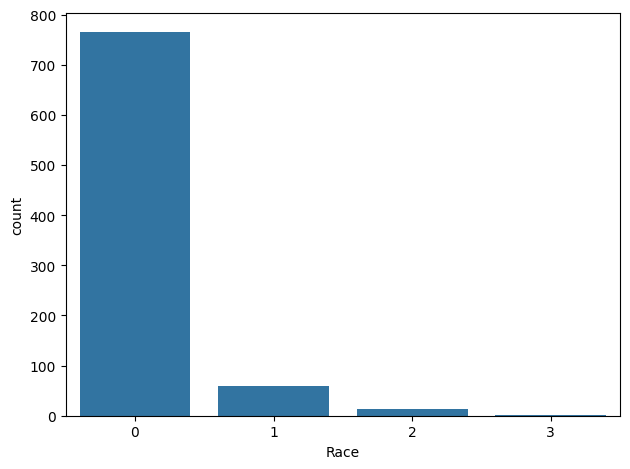

In [ ]:
racial_data = initialdata['Race'].value_counts()
print(racial_data)

display(racial_data * 100 / len(initialdata))

sns.countplot(data = initialdata, x = 'Race')
plt.tight_layout()
plt.show()

The race columns covers 4 groups:
*   0 = White
*   1 = Black or African American
*   2 = Asian
*   3 = American Indian or Alaska Native

There is a distinct imbalance in this dataset because 91% of the patients that are represented are 'White'. To promote fairness and mitigate bias while training the model, I will exclude the racial column for the initial testing. Race will be re-integrated to compare any differences in the model's prediction using race-aware resampling and fairness evaluations.




# Data To Use for Modelling

In [ ]:
data = initialdata.drop(columns=['Race'])
data.head()

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Identify feature types

In [ ]:
numeric_features = data['Age_at_diagnosis']
categorical_features = data['Gender']
mutation_features = data.drop(columns=['Age_at_diagnosis', 'Gender', 'Grade'])

## Check the Distribution of Mutation Variables

In [ ]:
summary = []
n = len(data)

for gene in mutation_features.columns: # Iterate through column names (gene names)
    counts = data[gene].value_counts().sort_index()
    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)
    pct_0 = (count_0 / n) * 100
    pct_1 = (count_1 / n) * 100

    summary.append({
        "Gene": gene,
        "# Non-Mutated": count_0,
        "# Mutated": count_1,
        "% Non-Mut": round(pct_0, 2),
        "% Mut": round(pct_1, 2)
    })

# === 4. Build & display the summary table ===
summary_df = pd.DataFrame(summary).sort_values("% Non-Mut", ascending=False).reset_index(drop=True)
display(summary_df)

,Gene,# Non-Mutated,# Mutated,% Non-Mut,% Mut
0,PDGFRA,817,22,97.38,2.62
1,IDH2,816,23,97.26,2.74
2,FAT4,816,23,97.26,2.74
3,SMARCA4,812,27,96.78,3.22
4,GRIN2A,812,27,96.78,3.22
5,CSMD3,812,27,96.78,3.22
6,BCOR,810,29,96.54,3.46
7,NOTCH1,801,38,95.47,4.53
8,RB1,799,40,95.23,4.77
9,FUBP1,794,45,94.64,5.36


## Correlation Heat Maps

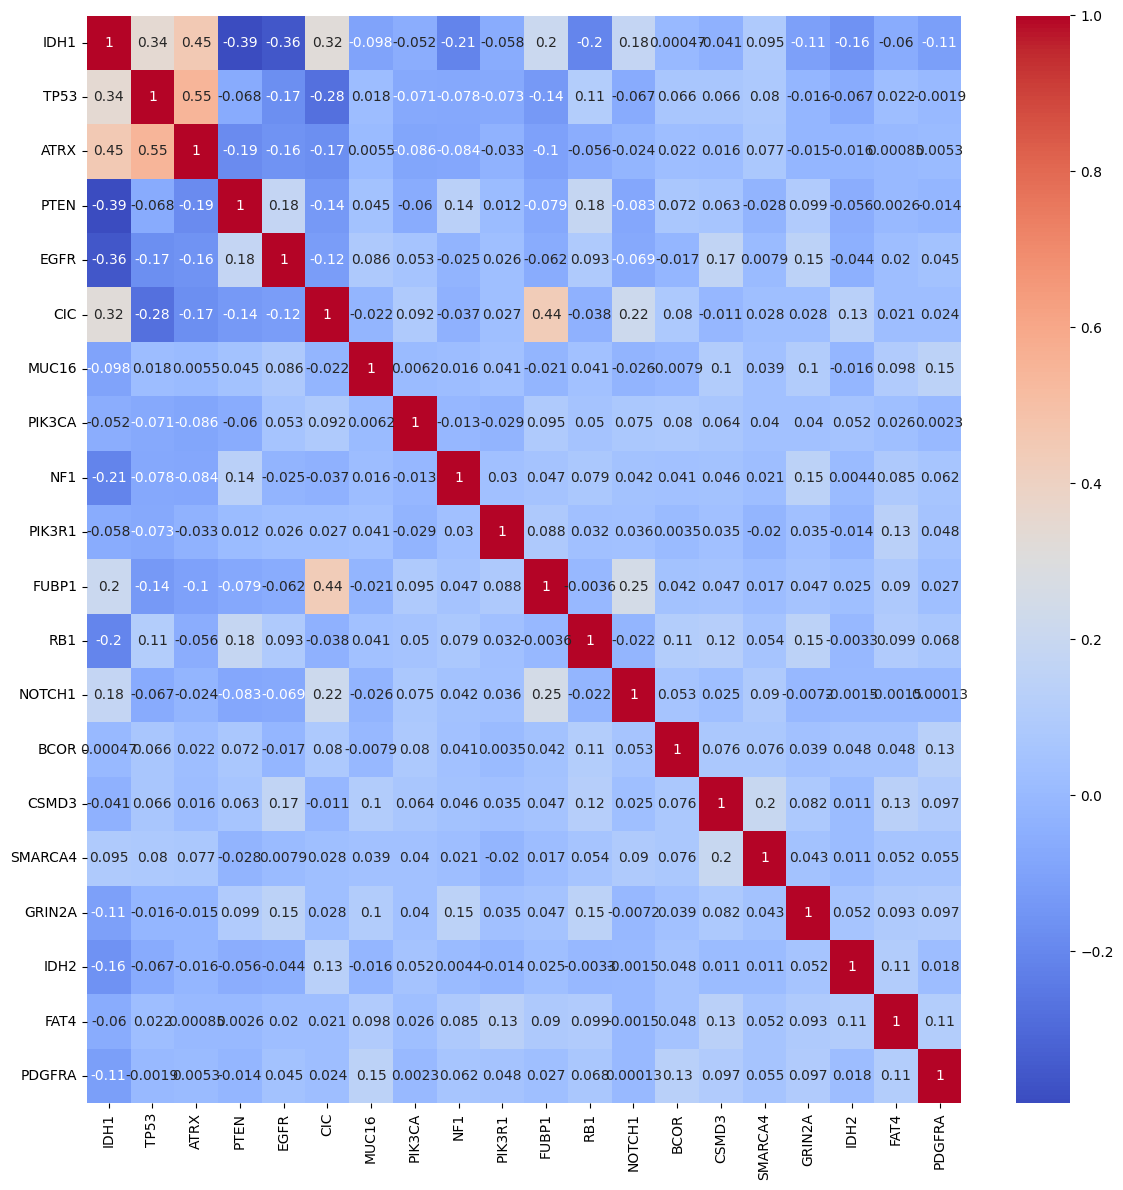

In [ ]:
#Gene Mutations Only
corr_map = mutation_features.corr()
plt.figure(figsize = (12, 12))
sns.heatmap(corr_map, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()


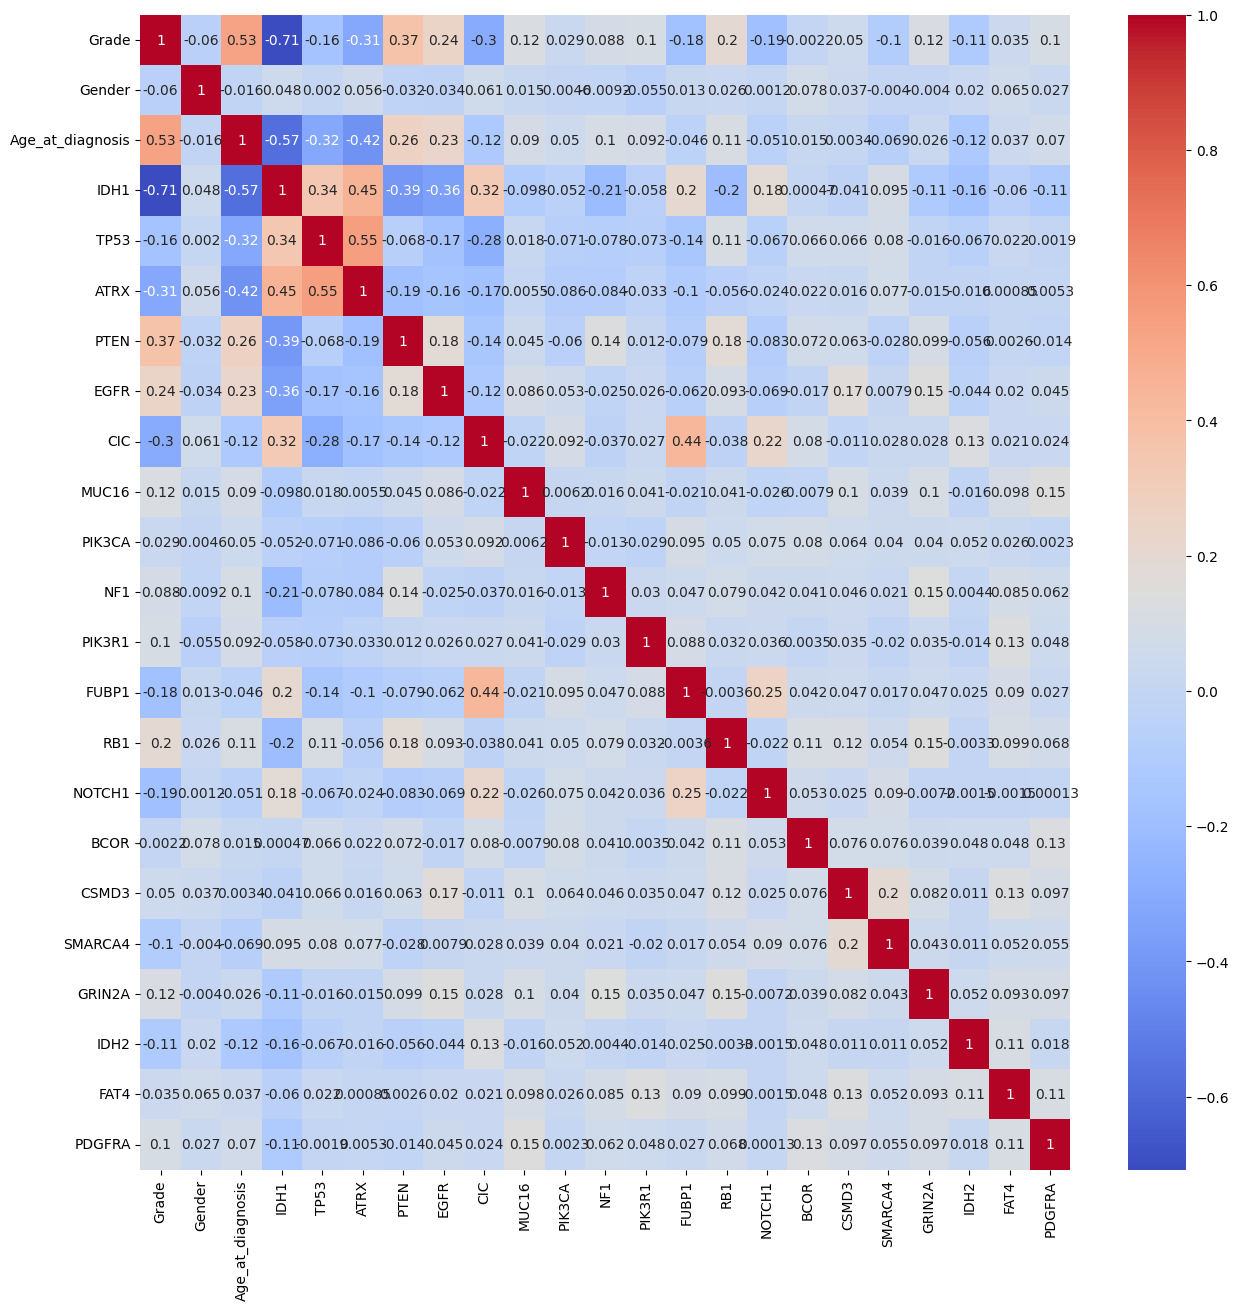

In [ ]:
#Clinical + Mutations
corr_map = data.corr()
plt.figure(figsize = (15, 15))
sns.heatmap(corr_map, annot=True, cmap='coolwarm')
plt.show()

# Model Preprocessing



In [ ]:
pip install pandas scikit-learn xgboost catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix,
    roc_curve, auc
)

In [ ]:
# Declare the variables
X = data.drop(columns=['Grade'])
y = data['Grade']

#Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train grade balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test grade balance:\n", y_test.value_counts(normalize=True).round(3))

# Scale Age_at_diagnosis
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled["Age_at_diagnosis"] = scaler.fit_transform(X_train[["Age_at_diagnosis"]])
X_test_scaled["Age_at_diagnosis"] = scaler.transform(X_test[["Age_at_diagnosis"]])

Train size: (671, 22)  Test size: (168, 22)
Train grade balance:
 Grade
0    0.58
1    0.42
Name: proportion, dtype: float64
Test grade balance:
 Grade
0    0.583
1    0.417
Name: proportion, dtype: float64


# Dimensionality Reduction + Neural Network

## PCA Dimensinality Reduction

In [ ]:
from sklearn.decomposition import PCA

n_components = 0.95

pca = PCA(n_components = n_components, random_state = 42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Number of Original Features:, {X_train_scaled.shape[1]}")
print(f"Number of PCA Components (95% Variance):, {X_train_pca.shape[1]}")

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
print(f"Explained Variance by Component: {explained_variance}")
print(f"Cumulative Explained Variance: {cumulative_variance}")

print(f"Original Data Shape: {X_train_scaled.shape}")
print(f"PCA Reduced Data Shape: {X_train_pca.shape}")

Number of Original Features:, 22
Number of PCA Components (95% Variance):, 16
Explained Variance by Component: [0.40914403 0.10080746 0.08372475 0.0755018  0.03938038 0.03692235
 0.03224226 0.03080525 0.02721557 0.02330017 0.02059795 0.01852294
 0.01484258 0.01400355 0.01227699 0.01164984]
Cumulative Explained Variance: [0.40914403 0.50995149 0.59367624 0.66917804 0.70855842 0.74548077
 0.77772303 0.80852828 0.83574385 0.85904402 0.87964197 0.89816491
 0.91300749 0.92701105 0.93928804 0.95093787]
Original Data Shape: (671, 22)
PCA Reduced Data Shape: (671, 16)


## Neural Network -- Feedforwarding with Tensorflow and Keras

In [ ]:
!pip3 install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

X_train_nn = X_train_pca
X_test_nn = X_test_pca

y_train_nn = np.array(y_train).astype(int)
y_test_nn = np.array(y_test).astype(int)

nn_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

history = nn_model.fit(
    X_train_nn, y_train_nn,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 16,
    verbose = 1
)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5893 - loss: 0.6631 - val_accuracy: 0.8148 - val_loss: 0.5377
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8336 - loss: 0.4945 - val_accuracy: 0.8296 - val_loss: 0.4332
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8219 - loss: 0.3957 - val_accuracy: 0.8444 - val_loss: 0.3954
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8789 - loss: 0.3205 - val_accuracy: 0.8370 - val_loss: 0.3815
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8581 - loss: 0.3393 - val_accuracy: 0.8370 - val_loss: 0.3760
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8701 - loss: 0.3241 - val_accuracy: 0.8370 - val_loss: 0.3696
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8688 - loss: 0.3314 - val_accuracy: 0.8370 - val_loss: 0.3695
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8744 - loss: 0.3026 - val_accuracy: 0.8370 - val_

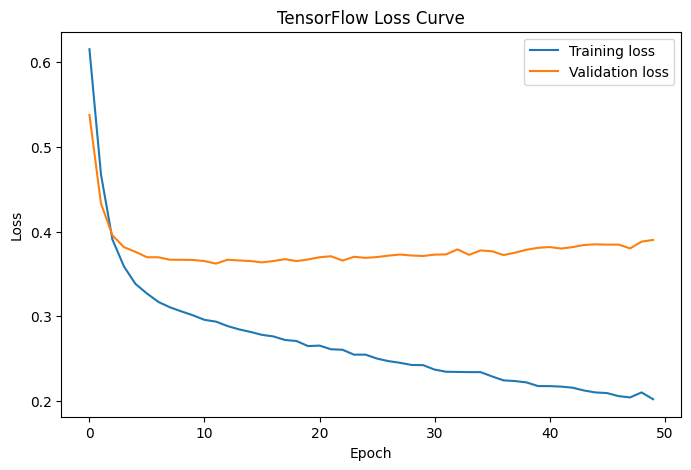

Test Loss: 0.36689236760139465
Test Accuracy: 0.8392857313156128
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
=== TensorFlow Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        98
           1       0.78      0.86      0.82        70

    accuracy                           0.84       168
   macro avg       0.83      0.84      0.84       168
weighted avg       0.84      0.84      0.84       168



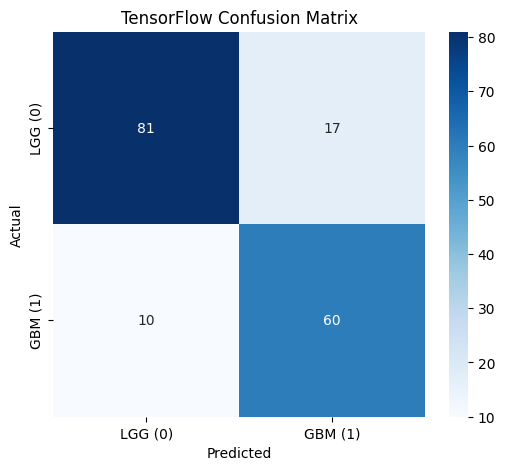

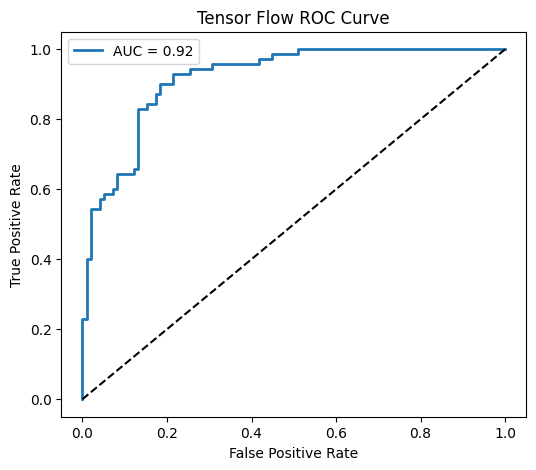

In [ ]:
#Plot Training + Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('TensorFlow Loss Curve')
plt.show()

#Evaluate Test Set
test_loss, test_accuracy = nn_model.evaluate(X_test_nn, y_test_nn, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predictions + Classification Report
y_pred_proba_nn = nn_model.predict(X_test_nn).ravel()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

print("=== TensorFlow Classification Report ===")
print(classification_report(y_test_nn, y_pred_nn))

#Confusion Matrix
nn_cm = confusion_matrix(y_test_nn, y_pred_nn)
plt.figure(figsize=(6, 5))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LGG (0)', 'GBM (1)'],
            yticklabels=['LGG (0)', 'GBM (1)'])
plt.title("TensorFlow Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_nn, y_pred_proba_nn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tensor Flow ROC Curve')
plt.legend()
plt.show()

## Neural Network -- Feedforwarding with PyTorch

In [ ]:
!pip3 install torch torchvision torchaudio

In [ ]:
# import relevant modules
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# convert PCA data to PyTorch sensors
X_train_tensor = torch.FloatTensor(X_train_pca)
y_train_tensor = torch.FloatTensor(np.array(y_train)).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_pca)
y_test_tensor = torch.FloatTensor(np.array(y_test)).view(-1, 1)

print("Tensor shape (Train):", X_train_tensor.shape)
print("Tensor shape (Test):", X_test_tensor.shape)

# setup feed-forward network model
nn_pytorch = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

print(nn_pytorch)

# loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_pytorch.parameters(), lr = 0.001)

# training loops
num_epochs = 50
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
  nn_pytorch.train() # for training
  optimizer.zero_grad()
  train_outputs = nn_pytorch(X_train_tensor)

  train_predicted = train_outputs.round()   #accuracy
  train_correct = (train_predicted == y_train_tensor).sum().item()
  train_acc = train_correct / y_train_tensor.size(0)
  train_accuracies.append(train_acc)

  loss = criterion(train_outputs, y_train_tensor)   #loss
  loss.backward()
  optimizer.step()
  train_losses.append(loss.item())

  nn_pytorch.eval() # for testing/validation
  with torch.no_grad():
    test_outputs = nn_pytorch(X_test_tensor)

    test_predicted = test_outputs.round()   #accuracy
    test_correct = (test_predicted == y_test_tensor).sum().item()
    test_acc = test_correct / y_test_tensor.size(0)
    test_accuracies.append(test_acc)

    test_loss = criterion(test_outputs, y_test_tensor)   #loss
    test_losses.append(test_loss.item())

Tensor shape (Train): torch.Size([671, 16])
Tensor shape (Test): torch.Size([168, 16])
Sequential(
  (0): Linear(in_features=16, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)


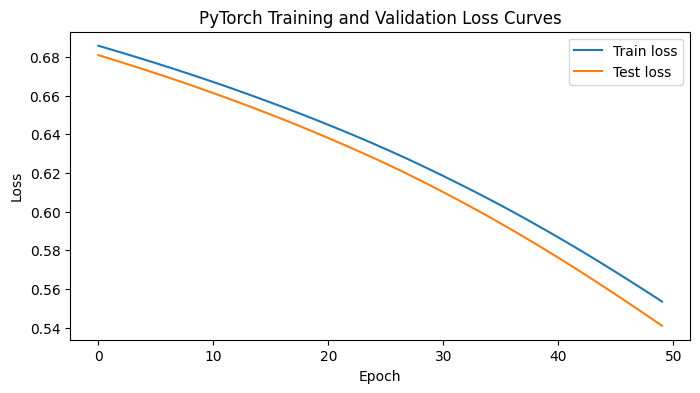

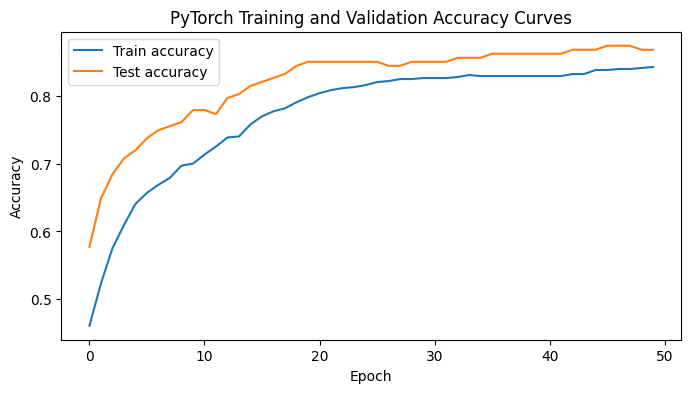

Test Loss: 0.5410250425338745
Test Accuracy: 0.8690476190476191
=== PyTorch Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        98
           1       0.81      0.90      0.85        70

    accuracy                           0.87       168
   macro avg       0.86      0.87      0.87       168
weighted avg       0.87      0.87      0.87       168



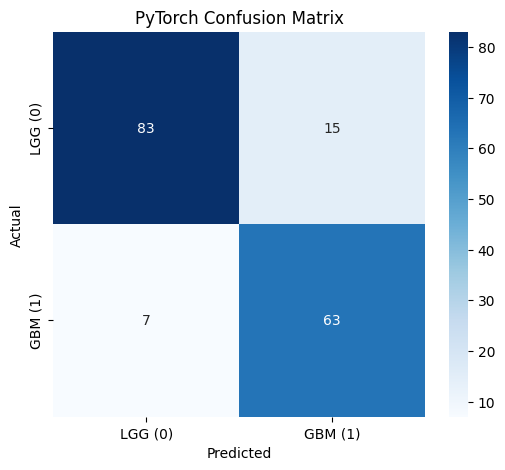

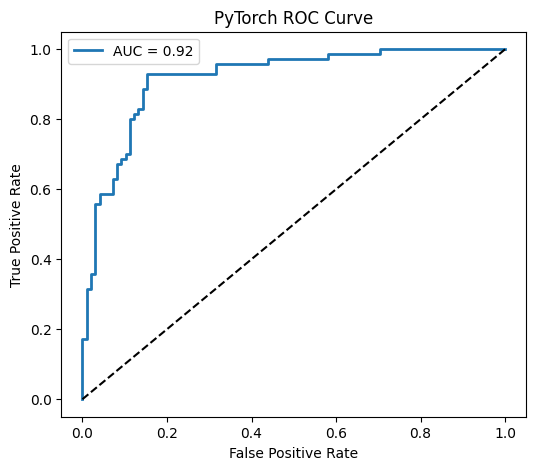

In [ ]:
# Plotting Loss + Accuracy
# Loss curves
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch Training and Validation Loss Curves')
plt.legend()
plt.show()

# Accuracy curves
plt.figure(figsize=(8,4))
plt.plot(train_accuracies, label='Train accuracy')
plt.plot(test_accuracies, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('PyTorch Training and Validation Accuracy Curves')
plt.legend()
plt.show()

# Eval Metrics
nn_pytorch.eval()
with torch.no_grad():
  probs = nn_pytorch(X_test_tensor).numpy().ravel()
  y_pred_pytorch = (probs >= 0.5).astype(int)

y_true = np.array(y_test)

# Retrieve final test loss and accuracy
final_test_loss = test_losses[-1]
final_test_accuracy = test_accuracies[-1]

print("Test Loss:", final_test_loss)
print("Test Accuracy:", final_test_accuracy)

# Classification Report
print("=== PyTorch Classification Report ===")
print(classification_report(y_true, y_pred_pytorch))

# Confusion Matrix
nn_pytorch_cm = confusion_matrix(y_true, y_pred_pytorch)
plt.figure(figsize=(6, 5))
sns.heatmap(nn_pytorch_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LGG (0)', 'GBM (1)'],
            yticklabels=['LGG (0)', 'GBM (1)'])
plt.title("PyTorch Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC/AUC Curve
fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PyTorch ROC Curve')
plt.legend()
plt.show()